<a href="https://colab.research.google.com/github/widura26/recap-automation/blob/main/recap_automation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Summary

Source : [link text](https://docs.google.com/spreadsheets/d/1Ibki18gicAFziEx1urTrvDv_KkzrkMMnRrbwqNYpOkw/edit?usp=sharing)

 List BOM
* Elektrik + Pre Series ✅ ✅
* De-Scoping ✅
* Interior ✅ ✅
* TMS ✅
* CKD VVVF ✅
* CKD Pantograph ✅
* CKD SIV ✅
* Elektrik ✅ ✅
* Komponen Utama ✅ ✅
* Sistem Mekanik ✅ ✅
* Raw Material Interior ✅
* Bogie KIT ✅
* Raw Material Bogie ✅
* Realisasi Raw Material ✅
* Carbody
* Fastening Mekanik
* Fastening Bogie
* Fastening Interior
* Crashwrothiness
* Welding
* Welding Bogie
* Consumable Tools ✅
* Consumable Series
* Welding WS BWI
* Jig Tools 6TS Pelokalan
* Jig Tool
* Tools ✅
* Tools & Consumable Tools Perbaikan ✅ ✅
* Consumable Pre Series ✅✅

---

Required data
*   Kode Material
*   Material (Nama material)
*   Spesifikasi
*   Qty / TS

In [2]:
from google.colab import auth
auth.authenticate_user()

import gspread
from google.auth import default
import pandas as pd
import re

# Grabbing data

In [70]:
creds, _ = default()
client = gspread.authorize(creds)

# 2. Buka Spreadsheet
nama_file_sheets = "bom_dataset"
spreadsheet = client.open(nama_file_sheets)

# --- LIST LENGKAP ALL 29 TARGET SHEET ---
DAFTAR_SHEET_TARGET = [
    "Elektrik + Pre Series",
    "De-Scoping",
    "Interior",
    "TMS",
    "CKD VVVF",
    "CKD Pantograph",
    "CKD SIV",
    "Elektrik",
    "Komponen Utama",
    "Sistem Mekanik",
    "Raw Material Interior",
    "Bogie KIT",
    "Raw Material Bogie",
    "Realisasi Raw Material",
    "Carbody",
    "Fastening Mekanik",
    "Fastening Bogie",
    "Fastening Interior",
    "Crashwrothiness",
    "Welding",
    "Welding Bogie",
    "Consumable Tools",
    "Consumable Series",
    "Welding WS BWI",
    "Jig Tools 6TS Pelokalan",
    "jig Tool",
    "Tools",
    "Tools & Consumable Tools Perbaikan",
    "Consumable Pre Series"
]

semua_tab = spreadsheet.worksheets()
sheet_names_aktual = [sheet.title for sheet in semua_tab]

def cari_sheet_aktual(nama_target):
    target_clean = nama_target.strip().lower()
    for actual in sheet_names_aktual:
        if actual.strip().lower() == target_clean:
            return actual
    target_alphanumeric = re.sub(r'[^a-z0-9]', '', target_clean)
    for actual in sheet_names_aktual:
        actual_alphanumeric = re.sub(r'[^a-z0-9]', '', actual.strip().lower())
        if target_alphanumeric == actual_alphanumeric:
            return actual
    return None

target_sheets_matched = []
for nama_target in DAFTAR_SHEET_TARGET:
    matched = cari_sheet_aktual(nama_target)
    if matched and matched not in target_sheets_matched:
        target_sheets_matched.append(matched)

print(f"[INFO] Memetakan {len(target_sheets_matched)} dari {len(DAFTAR_SHEET_TARGET)} target sheet.\n")

KATA_KUNCI = {
    # 'kode': ['kode material', 'kode barang', 'item code', 'part number', 'kode', 'material code', 'no. part', 'part no', 'k o d e'],
    'kode': ['Kode Material'],
    # 'nama': ['material / komponen', 'material/komponen', 'nama barang', 'nama material', 'description', 'komponen', 'material name', 'item description', 'nama komponen', 'uraian', 'nama/spesifikasi', 'Deskripsi Material'],
    'nama': ['material / komponen', 'material/komponen', 'deskripsi material'],
    # 'spek': ['spesifikasi', 'specification', 'spek', 'ukuran', 'dimensi', 'spec', 'Spesifikasi'],
    'spek': ['spesifikasi', 'specification', 'Spesifikasi', 'Specification', 'SPESIFIKASI'],
    # 'qty' : ['qty / ts', 'qty/ts', 'quantity', 'qty', 'jumlah', 'total qty', 'ts', 'qty total', 'total', 'vol', 'volume', 'qty/set', 'qty / set', 'set', 'Qty/TS (Series)']
    'qty' : [
        'qty/ts (series)', 'qty / ts (series)', 'qty/ts(series)', 'qty / ts(series)',
        # 'qty total (series)', 'qty total(series)', 'total qty (series)',
        # 'qty/set (series)', 'qty/set(series)', 'qty (series)'
    ]
}

rekap_data = []

for target_name in target_sheets_matched:
    sheet = spreadsheet.worksheet(target_name)
    data_mentah = sheet.get_all_values()

    if len(data_mentah) < 3:
        print(f"Sheet '{target_name}' -> [SKIP] Baris kosong.")
        continue

    # 1. CARI HEADER HINGGA BARIS 50 (Penting untuk Jig Tool, Consumable, dsb.)
    header_idx = -1
    idx_kode = idx_nama = idx_spek = idx_qty = None

    for r_idx in range(min(50, len(data_mentah))):
        row_str = [str(c).strip().lower() for c in data_mentah[r_idx]]
        row_text_full = " ".join(row_str)

        if any(k in row_text_full for k in ['kode', 'part', 'material', 'komponen', 'description', 'uraian']):
            for c_idx, cell in enumerate(row_str):
                if idx_kode is None and any(k in cell for k in KATA_KUNCI['kode']):
                    idx_kode = c_idx
                if idx_nama is None and any(k in cell for k in KATA_KUNCI['nama']):
                    idx_nama = c_idx
                if idx_spek is None and any(k in cell for k in KATA_KUNCI['spek']):
                    idx_spek = c_idx
                if idx_qty is None and any(k in cell for k in KATA_KUNCI['qty']):
                    idx_qty = c_idx

            if idx_kode is not None or idx_nama is not None:
                header_idx = r_idx
                break

    # Fallback jika header tidak ketemu lewat kata kunci
    if header_idx == -1: header_idx = 7
    if idx_kode is None: idx_kode = 4   # Kolom E
    if idx_nama is None: idx_nama = 11  # Kolom L
    if idx_spek is None: idx_spek = 13  # Kolom N
    if idx_qty is None:  idx_qty = 30   # Kolom AE

    baris_terproses = 0

    for row in data_mentah[header_idx + 1:]:
        max_idx = max(idx_kode, idx_nama, idx_spek, idx_qty)
        while len(row) <= max_idx + 10:
            row.append("")

        kode_material = str(row[idx_kode]).strip()
        nama_material = row[idx_nama]
        spesifikasi = row[idx_spek] if idx_spek < len(row) else ""

        # 2. SMARTEST QTY SEARCH: Ambil dari idx_qty, jika tidak ada cari angka pertama setelah kolom Nama
        raw_qty = row[idx_qty]

        valid_qty = None
        str_qty = str(raw_qty).strip().replace(',', '.').upper()

        # Ekstrak angka dari Qty Utama
        if str_qty not in ["N/A", "-", "#N/A", "#VALUE!", ""]:
            match = re.search(r'-?\d+(\.\d+)?', str_qty)
            if match:
                valid_qty = float(match.group(0))

        # Jika Qty Utama gagal/kosong, pindai 5 kolom di kanan idx_nama & idx_qty
        # if valid_qty is None:
        #     for check_idx in range(idx_nama + 1, len(row)):
        #         val = str(row[check_idx]).strip().replace(',', '.')
        #         match = re.search(r'^-?\d+(\.\d+)?$', val)
        #         if match:
        #             valid_qty = float(match.group(0))
        #             break

        if valid_qty is None:
            valid_qty = 0.0


        kata_abaikan = ["kode material", "kode", "total", "subtotal", "header", "item code", "part number", "k o d e"]

        if kode_material and kode_material.lower() not in kata_abaikan and valid_qty is not None:
            rekap_data.append([
                target_name,
                kode_material,
                nama_material,
                spesifikasi,
                valid_qty
            ])
            baris_terproses += 1

    print(f"Sheet '{target_name}' (Header Baris {header_idx+1}) -> {baris_terproses} baris terambil.")

# --- OUTPUT TO SPREADSHEET ---
df_rekap = pd.DataFrame(rekap_data, columns=[
    "Nama Sheet Sumber", "Kode Material", "Material / Komponen", "Spesifikasi", "Qty / TS"
])

print("\n--- RINGKASAN HASIL PER SHEET ---")
print(df_rekap.groupby("Nama Sheet Sumber").size())

nama_tab_rekap = "REKAP_BOM_TOTAL (Berdasarkan Kode Material) 2"
try:
    sheet_rekap = spreadsheet.worksheet(nama_tab_rekap)
    sheet_rekap.clear()
except gspread.exceptions.WorksheetNotFound:
    sheet_rekap = spreadsheet.add_worksheet(title=nama_tab_rekap, rows="6000", cols="5")

data_ke_sheets = [df_rekap.columns.values.tolist()] + df_rekap.values.tolist()
sheet_rekap.update(data_ke_sheets)

print(f"\n[SUKSES] TOTAL {len(df_rekap)} baris data berhasil ditarik dari {df_rekap['Nama Sheet Sumber'].nunique()} sheet BOM.")

[INFO] Memetakan 29 dari 29 target sheet.

Sheet 'Elektrik + Pre Series' (Header Baris 6) -> 354 baris terambil.
Sheet 'De-Scoping' (Header Baris 3) -> 745 baris terambil.
Sheet 'Interior' (Header Baris 6) -> 339 baris terambil.
Sheet 'TMS' (Header Baris 6) -> 21 baris terambil.
Sheet 'CKD VVVF' (Header Baris 6) -> 147 baris terambil.
Sheet 'CKD Pantograph' (Header Baris 6) -> 266 baris terambil.
Sheet 'CKD SIV' (Header Baris 6) -> 119 baris terambil.
Sheet 'Elektrik' (Header Baris 6) -> 434 baris terambil.
Sheet 'Komponen Utama' (Header Baris 6) -> 118 baris terambil.
Sheet 'Sistem Mekanik' (Header Baris 4) -> 497 baris terambil.
Sheet 'Raw Material Interior' (Header Baris 6) -> 76 baris terambil.
Sheet 'Bogie KIT' (Header Baris 6) -> 44 baris terambil.
Sheet 'Raw Material Bogie' (Header Baris 6) -> 94 baris terambil.
Sheet 'Realisasi Raw Material' (Header Baris 4) -> 124 baris terambil.
Sheet 'Carbody' (Header Baris 6) -> 246 baris terambil.
Sheet 'Fastening Mekanik' (Header Baris 6)

# Read data

In [ ]:
urx = "https://docs.google.com/spreadsheets/d/1Ibki18gicAFziEx1urTrvDv_KkzrkMMnRrbwqNYpOkw/export?format=csv&gid=1686922189"

data = pd.read_csv(urx, low_memory=False)
data.head()

,Nama Sheet Sumber,Kode Material,Material / Komponen,Spesifikasi,Qty / TS
0,Elektrik + Pre Series,B336E12101,ELVP TC,Refer to dwg. 33.6-E12101 & 86.2-E12104 86.2-E...,2.0
1,Elektrik + Pre Series,B336E12201,ELVP M1,Refer to dwg. 33.6-E12201 & 86.2-E12204 86.2-E...,3.0
2,Elektrik + Pre Series,B336E12301,ELVP M2,Refer to dwg. 33.6-E12301 & 86.2-E12304 86.2-E...,3.0
3,Elektrik + Pre Series,B336E12401,ELVP T1,"Refer to dwg. 33.6-E12401 & 86.2-E12404, 86.2...",2.0
4,Elektrik + Pre Series,B336E12501,ELVP T2,Refer to dwg. 33.6-E12501 & 86.2-E12504 86.2-E...,1.0


# Analyze data

In [ ]:
ckdpantographData = data[data["Nama Sheet Sumber"] == "CKD Pantograph"]
ckdpantographData[ckdpantographData["Material / Komponen"].isna()]

,Nama Sheet Sumber,Kode Material,Material / Komponen,Spesifikasi,Qty / TS
1862,CKD Pantograph,B52TP5088,NaN,NaN,1.0
1863,CKD Pantograph,B52TP5089,NaN,NaN,1.0
1864,CKD Pantograph,B52TP5090,NaN,NaN,1.0


In [ ]:
ckdsivdata = data[data["Nama Sheet Sumber"] == "CKD SIV"]
ckdsivdata[ckdsivdata["Material / Komponen"].isna()]

,Nama Sheet Sumber,Kode Material,Material / Komponen,Spesifikasi,Qty / TS
1977,CKD SIV,B42CD0416,NaN,NaN,0.0
1982,CKD SIV,B44LA0008,NaN,NaN,100.0


In [ ]:
carbodydata = data[data["Nama Sheet Sumber"] == "Carbody"]
carbodydata[carbodydata["Material / Komponen"].isna()].head()

,Nama Sheet Sumber,Kode Material,Material / Komponen,Spesifikasi,Qty / TS
3418,Carbody,BRACKET,NaN,NaN,0.0


In [ ]:
fasteningmekanikdata = data[data["Nama Sheet Sumber"] == "Fastening Mekanik"]
fasteningmekanikdata[fasteningmekanikdata["Material / Komponen"].isna()].head()

,Nama Sheet Sumber,Kode Material,Material / Komponen,Spesifikasi,Qty / TS
4159,Fastening Mekanik,B46NG0424,NaN,NaN,432.0


In [ ]:
rrmdata = data[data["Nama Sheet Sumber"] == "Realisasi Raw Material"]
rrmdata[rrmdata["Material / Komponen"].isna()]

,Nama Sheet Sumber,Kode Material,Material / Komponen,Spesifikasi,Qty / TS
3295,Realisasi Raw Material,A11BU0050,NaN,NaN,0.33
3316,Realisasi Raw Material,A11ND0160,NaN,NaN,0.04
3325,Realisasi Raw Material,A11ZJ0010,NaN,NaN,10.04
3346,Realisasi Raw Material,A15ND0230,NaN,NaN,0.05
3348,Realisasi Raw Material,A15SA0240,NaN,NaN,0.08
3350,Realisasi Raw Material,A15ZD0160,NaN,NaN,0.05
3374,Realisasi Raw Material,A11AA0045,NaN,NaN,3.00
3376,Realisasi Raw Material,A11AA0090,NaN,NaN,2.00


In [ ]:
result = data[data["Material / Komponen"].isna()]
result.groupby("Nama Sheet Sumber").size()

,0
Nama Sheet Sumber,
CKD Pantograph,3
CKD SIV,2
Carbody,1
Fastening Mekanik,1
Realisasi Raw Material,8


In [ ]:
spesifikasiisnaresult = data[data["Spesifikasi"].isna()]
spesifikasiisnaresult.groupby("Nama Sheet Sumber").size()

,0
Nama Sheet Sumber,
Bogie KIT,1
CKD Pantograph,3
CKD SIV,2
Carbody,1
Consumable Pre Series,2
Consumable Series,14
Consumable Tools,11
Crashwrothiness,1
De-Scoping,25


In [ ]:
bkdata = data[data["Nama Sheet Sumber"] == "Bogie KIT"]
bkdata[bkdata["Spesifikasi"].isna()]

,Nama Sheet Sumber,Kode Material,Material / Komponen,Spesifikasi,Qty / TS
3138,Bogie KIT,B52TP3101,Eathing Brush,NaN,24.0


In [ ]:
ckdpdata = data[data["Nama Sheet Sumber"] == "CKD Pantograph"]
ckdpdata[ckdpdata["Spesifikasi"].isna()]

,Nama Sheet Sumber,Kode Material,Material / Komponen,Spesifikasi,Qty / TS
1862,CKD Pantograph,B52TP5088,NaN,NaN,1.0
1863,CKD Pantograph,B52TP5089,NaN,NaN,1.0
1864,CKD Pantograph,B52TP5090,NaN,NaN,1.0


In [ ]:
cdata = data[data["Nama Sheet Sumber"] == "Carbody"]
cdata[cdata["Spesifikasi"].isna()]

,Nama Sheet Sumber,Kode Material,Material / Komponen,Spesifikasi,Qty / TS
3418,Carbody,BRACKET,NaN,NaN,0.0


In [ ]:
cpsdata = data[data["Nama Sheet Sumber"] == "Consumable Pre Series"]
cpsdata[cpsdata["Spesifikasi"].isna()]
#bermasalah nih kalkulasi quantitynya.

,Nama Sheet Sumber,Kode Material,Material / Komponen,Spesifikasi,Qty / TS
6993,Consumable Pre Series,D66UQ0001#BC,LAKBAN HITAM,NaN,0.0
7064,Consumable Pre Series,D68QH0125,ANTISOL E 125,NaN,0.0


In [ ]:
cpsdata = data[data["Nama Sheet Sumber"] == "Consumable Pre Series"]
cpsdata[cpsdata["Qty / TS"] != 0.0]

,Nama Sheet Sumber,Kode Material,Material / Komponen,Spesifikasi,Qty / TS
6984,Consumable Pre Series,D51QC0048,SEAL TAPE DCOTA,DCOTA 48ROLL/PA,200.0


In [ ]:
csdata = data[data["Nama Sheet Sumber"] == "Consumable Series"]
csdata[csdata["Spesifikasi"].isna()] #bermasalah nih ada beberapa data yang nggak masuk

,Nama Sheet Sumber,Kode Material,Material / Komponen,Spesifikasi,Qty / TS
5506,Consumable Series,D66UQ0001#BC,LAKBAN HITAM,NaN,408.0
5576,Consumable Series,D68QH0125,ANTISOL E 125,NaN,60.0
5600,Consumable Series,D82WL0001,BENANG NILON,NaN,120.0
5620,Consumable Series,D68QH1004,LEM G,NaN,48.0
5631,Consumable Series,D66UQ0001#BC,LAKBAN HITAM,NaN,12.0
5638,Consumable Series,D31WH0506,TECTYL 506,NaN,12.0
5653,Consumable Series,D67UK0002,MAJUN,NaN,24.0
5667,Consumable Series,D68QG0005,Danagloss Polyester Putty ( Dempul ),NaN,6.0
5668,Consumable Series,D62QE0088#HB,Sigmafast 278 + Hardener,NaN,10.0
5669,Consumable Series,D63SA0017,Kertas Gosok No.1,NaN,20.0


In [ ]:
csdata = data[(data["Nama Sheet Sumber"] == "Consumable Series") & (data["Kode Material"] == "D66UG0048-NCI")]
csdata

,Nama Sheet Sumber,Kode Material,Material / Komponen,Spesifikasi,Qty / TS
5505,Consumable Series,D66UG0048-NCI,ISOLASI KERTAS,UKURAN 48MM,708.0
5630,Consumable Series,D66UG0048-NCI,ISOLASI KERTAS,UKURAN 48MM,12.0


In [ ]:
crsdata = data[data["Nama Sheet Sumber"] == "Crashwrothiness"]
crsdata[crsdata["Spesifikasi"].isna()]

,Nama Sheet Sumber,Kode Material,Material / Komponen,Spesifikasi,Qty / TS
5134,Crashwrothiness,B43KR1001,NUT_HEX_M10XP1.5_10T,NaN,15.0


In [ ]:
dsdata = data[data["Nama Sheet Sumber"] == "De-Scoping"]
dsdata[dsdata["Spesifikasi"].isna()]

,Nama Sheet Sumber,Kode Material,Material / Komponen,Spesifikasi,Qty / TS
363,De-Scoping,D66UQ0001#BC,LAKBAN HITAM,NaN,408.0
433,De-Scoping,D68QH0125,ANTISOL E 125,NaN,60.0
457,De-Scoping,D82WL0001,BENANG NILON,NaN,120.0
477,De-Scoping,D68QH1004,LEM G,NaN,48.0
488,De-Scoping,D66UQ0001#BC,LAKBAN HITAM,NaN,12.0
495,De-Scoping,D31WH0506,TECTYL 506,NaN,12.0
510,De-Scoping,D67UK0002,MAJUN,NaN,24.0
524,De-Scoping,D68QG0005,Danagloss Polyester Putty ( Dempul ),NaN,6.0
525,De-Scoping,D62QE0088#HB,Sigmafast 278 + Hardener,NaN,10.0
526,De-Scoping,D63SA0017,Kertas Gosok No.1,NaN,20.0


In [ ]:

elektrikData = data[data["Nama Sheet Sumber"] == "Elektrik"]
elektrikData[elektrikData["Spesifikasi"].isna()]

,Nama Sheet Sumber,Kode Material,Material / Komponen,Spesifikasi,Qty / TS
2198,Elektrik,D83SP0101,BALLPOINT OPF,NaN,10.0
2281,Elektrik,B52TG1213CPU,CPU,NaN,2.0
2282,Elektrik,B52TG1213AG,GPS ANTENA,NaN,2.0
2283,Elektrik,B52TG1213HMI,PIS & PAS HMI,NaN,2.0
2284,Elektrik,B52TG1213SW,ETH SWITCH,NaN,12.0
2285,Elektrik,B52TG1213AM,AMPLIFIER,NaN,12.0
2286,Elektrik,B52TG1213FDI,FRONT DESTINATION INDICATOR,NaN,2.0
2287,Elektrik,B52TG1213RTO,SIDE LED RUNNING TEXT,NaN,24.0
2288,Elektrik,B52TG1213WLCD,PAS MONITOR,NaN,96.0
2289,Elektrik,B52TG1213DIG,IO PIS & PAS MODULE,NaN,2.0


In [ ]:
elektrikData = data[data["Nama Sheet Sumber"] == "Elektrik + Pre Series"]
elektrikData[elektrikData["Spesifikasi"].isna()]

,Nama Sheet Sumber,Kode Material,Material / Komponen,Spesifikasi,Qty / TS
161,Elektrik + Pre Series,A04WG3032,Hose Vinil 30X32 MM,NaN,48.0
207,Elektrik + Pre Series,D83SP0101,BALLPOINT OPF,NaN,10.0
295,Elektrik + Pre Series,B43KC0407,NUT_HEX_M4xP0.7_SUS,NaN,16.0
300,Elektrik + Pre Series,B52TG1213CPU,CPU,NaN,2.0
301,Elektrik + Pre Series,B52TG1213AG,GPS ANTENA,NaN,2.0
302,Elektrik + Pre Series,B52TG1213HMI,PIS & PAS HMI,NaN,2.0
303,Elektrik + Pre Series,B52TG1213SW,ETH SWITCH,NaN,12.0
304,Elektrik + Pre Series,B52TG1213AM,AMPLIFIER,NaN,12.0
305,Elektrik + Pre Series,B52TG1213FDI,FRONT DESTINATION INDICATOR,NaN,2.0
306,Elektrik + Pre Series,B52TG1213RTO,SIDE LED RUNNING TEXT,NaN,24.0


In [ ]:
fmdata = data[data["Nama Sheet Sumber"] == "Fastening Mekanik"]
fmdata[fmdata["Spesifikasi"].isna()]

,Nama Sheet Sumber,Kode Material,Material / Komponen,Spesifikasi,Qty / TS
3952,Fastening Mekanik,B42CA101530,BOLT_HEX_JIS B1180,NaN,22.0
4159,Fastening Mekanik,B46NG0424,NaN,NaN,432.0
4435,Fastening Mekanik,B45MS0225,PIN_SPLIT_DIA2.5X25_SUS,NaN,4.0
4474,Fastening Mekanik,B41BE040710,SCREW_CSK_HEAD_JIS B1111,NaN,24.0
4534,Fastening Mekanik,B44LF0005,WASHER_SPRING_M5_SUS,NaN,96.0


In [ ]:
jtdata = data[data["Nama Sheet Sumber"] == "Jig Tool"]
jtdata[jtdata["Spesifikasi"].isna()]

,Nama Sheet Sumber,Kode Material,Material / Komponen,Spesifikasi,Qty / TS
6271,Jig Tool,B42CH2015,DYNA BOLT M20 X 150 MM,NaN,50.0


In [ ]:
jt6data = data[data["Nama Sheet Sumber"] == "Jig Tools 6TS Pelokalan"]
jt6data[jt6data["Spesifikasi"].isna()] #Bermasalah ini di Qty / TS

,Nama Sheet Sumber,Kode Material,Material / Komponen,Spesifikasi,Qty / TS
5715,Jig Tools 6TS Pelokalan,C86VC0001,1 SET OBENG KECIL -/+,NaN,0.0
5718,Jig Tools 6TS Pelokalan,C86UH6242,"Cleaner, TIP Solder Iron Mesh",NaN,0.0
5779,Jig Tools 6TS Pelokalan,D83SK0100,RANTAI PLASTIK WARNA MERAH,NaN,0.0
5929,Jig Tools 6TS Pelokalan,D66QG4608,LEM AICA,NaN,0.0
5933,Jig Tools 6TS Pelokalan,D83SP0101,BALLPOINT OPF,NaN,0.0
5954,Jig Tools 6TS Pelokalan,D29TC0010,SOLDER RH.50 (TIMAH),NaN,0.0
5958,Jig Tools 6TS Pelokalan,D66UG0015,ISOLASI KERTAS,NaN,0.0
5959,Jig Tools 6TS Pelokalan,D83SK0050,POLICE LINE MOTIF HITAM KUNING,NaN,0.0
5963,Jig Tools 6TS Pelokalan,D83SP02001,SAPU LANTAI,NaN,0.0
5964,Jig Tools 6TS Pelokalan,D83SP02002,CIKRAK,NaN,0.0


In [ ]:
jt6data = data[data["Nama Sheet Sumber"] == "Jig Tools 6TS Pelokalan"]
jt6data[jt6data["Qty / TS"] != 0.0]

,Nama Sheet Sumber,Kode Material,Material / Komponen,Spesifikasi,Qty / TS
5706,Jig Tools 6TS Pelokalan,C90HG0287,Digital Multimeter,Merk FLUKE 287,5.0
5707,Jig Tools 6TS Pelokalan,E97BC1500,HYDRAULIC SCISSOR LIFT TABLE,cap 800kg,10.0
5708,Jig Tools 6TS Pelokalan,C92RR0594,SOCKET SET,TEKIRO SC-SE0594,5.0
5709,Jig Tools 6TS Pelokalan,C89JI11510,KUNCI L,"HEXAGONAL 1,5-10 mm",10.0
5710,Jig Tools 6TS Pelokalan,C88MF0726,Tang Potong,KEIBA PL 726\t,30.0
5711,Jig Tools 6TS Pelokalan,C88MF0001,Tang Potong,Fujiya,10.0
5712,Jig Tools 6TS Pelokalan,C93RG0001,Mesin obeng listrik,"Rechargable Type mata obeng : min, plus, torx,...",6.0
5713,Jig Tools 6TS Pelokalan,C93FM1100,Obeng moment/torsi,"Kapasitas torsi 1-10 Nm, Type mata obeng : min...",4.0


In [ ]:
kudata = data[data["Nama Sheet Sumber"] == "Komponen Utama"]
kudata[kudata["Spesifikasi"].isna()]

,Nama Sheet Sumber,Kode Material,Material / Komponen,Spesifikasi,Qty / TS
2425,Komponen Utama,B40KA1201,Underframe Assembly,NaN,12.0
2426,Komponen Utama,B40KA1201,Side Wall Assembly,NaN,24.0
2427,Komponen Utama,B40KA1201,Roof Assembly of Carbody,NaN,12.0
2428,Komponen Utama,B40KA1201,End Wall Assembly of Carbody,NaN,22.0
2429,Komponen Utama,B40KA1201,Rain Gutter,NaN,12.0
2430,Komponen Utama,B40KA1201,Partition Frame,NaN,2.0
2431,Komponen Utama,B40KA1201,Cab Mask,NaN,2.0
2432,Komponen Utama,B40KA1201,Floor,NaN,12.0
2472,Komponen Utama,B463A170021,First Aid,NaN,12.0
2482,Komponen Utama,B52AC0143,Driver cab's door,NaN,4.0


In [ ]:
rawdata = data[data["Nama Sheet Sumber"] == "Realisasi Raw Material"]
rawdata[rawdata["Spesifikasi"].isna()]

,Nama Sheet Sumber,Kode Material,Material / Komponen,Spesifikasi,Qty / TS
3295,Realisasi Raw Material,A11BU0050,NaN,NaN,0.33
3316,Realisasi Raw Material,A11ND0160,NaN,NaN,0.04
3325,Realisasi Raw Material,A11ZJ0010,NaN,NaN,10.04
3346,Realisasi Raw Material,A15ND0230,NaN,NaN,0.05
3348,Realisasi Raw Material,A15SA0240,NaN,NaN,0.08
3350,Realisasi Raw Material,A15ZD0160,NaN,NaN,0.05
3374,Realisasi Raw Material,A11AA0045,NaN,NaN,3.00
3376,Realisasi Raw Material,A11AA0090,NaN,NaN,2.00


In [ ]:
smdata = data[data["Nama Sheet Sumber"] == "Sistem Mekanik"]
smdata[smdata["Spesifikasi"].isna()] #Anomali nih Qty nya

,Nama Sheet Sumber,Kode Material,Material / Komponen,Spesifikasi,Qty / TS
2575,Sistem Mekanik,B48BQ8518,SPRING,NaN,6.0
2600,Sistem Mekanik,A11ND0020,STEEL PLATE,NaN,0.0
2602,Sistem Mekanik,A15ND0030,ROUND BAR,NaN,0.0
2624,Sistem Mekanik,B51QN6161,ROUND PLUG,NaN,0.0
2729,Sistem Mekanik,A16HD02178,STEEL PIPE,NaN,0.0
2849,Sistem Mekanik,A11RF0020,STEEL PLATE,NaN,0.0
2852,Sistem Mekanik,A11RF0020,STEEL PLATE,NaN,0.0
2975,Sistem Mekanik,A11AB0023,STEEL PLATE,NaN,0.0
3026,Sistem Mekanik,B51ND1025B,BALLVALVE,NaN,2.0


In [ ]:
smdata = data[data["Nama Sheet Sumber"] == "Sistem Mekanik"]
smdata[smdata["Qty / TS"] != 0.0]

,Nama Sheet Sumber,Kode Material,Material / Komponen,Spesifikasi,Qty / TS
2543,Sistem Mekanik,A11AB0045,STEEL PLATE,SS400 T.4.5X1200X2400,16.40
2544,Sistem Mekanik,A11AB0060,STEEL PLATE,SS400 T.6X1200X2400,15.20
2545,Sistem Mekanik,A16NG0217,STEEL PIPE,"SUS 304, DIA 21,7 X 3,7 X 6000",2.40
2546,Sistem Mekanik,A11ND0010,STEEL PLATE,SUS 304 T.1 X1200X2400,6.30
2547,Sistem Mekanik,A11ND0020,STEEL PLATE,SUS 304 T2 X 1200 X 2400,0.45
...,...,...,...,...,...
3035,Sistem Mekanik,A10WG0030#GR,HARD VINYL,T. 3 X1200 X2400(GRAY,0.06
3036,Sistem Mekanik,A11ZD0200,TEFLON,"Teflon,T20 x 1200 x 1200",0.30
3037,Sistem Mekanik,A10PW0350D7,PERTINAK,t. 35x1000x2000,0.15
3038,Sistem Mekanik,B50LC0002,SILICONE BUMPER PANJANG,10x63mm,600.00


In [ ]:
toolsData = data[data["Nama Sheet Sumber"] == "Tools"]
toolsData[toolsData["Spesifikasi"].isna()] #Qty nya juga salah ini, nggak akurat

,Nama Sheet Sumber,Kode Material,Material / Komponen,Spesifikasi,Qty / TS
6410,Tools,C86LE0004,"PALU 0,5 LBs",NaN,0.0
6531,Tools,D88HH00301,ISI CUTTER BESAR,NaN,0.0
6551,Tools,C86ME1109,TANG JEPIT,NaN,0.0
6556,Tools,C88QE0250,KIKIR PLATE + GAGANG,NaN,1.0
6571,Tools,D79SP0020,KAPI SCRUB,NaN,0.0
6573,Tools,C79RA0003,LEPAN,NaN,0.0
6574,Tools,C79RA0004,CETOK,NaN,0.0
6575,Tools,C90HI0001,TIMBANGAN DUDUK,NaN,0.0
6855,Tools,C86VC0004,"OBENG (-) 5""",NaN,2.0
6856,Tools,C87SE0008,WIRE STRIPPER (PENGUPAS),NaN,1.0


In [ ]:
toolsData = data[data["Nama Sheet Sumber"] == "Tools"]
toolsData[toolsData["Qty / TS"] != 0.0]

,Nama Sheet Sumber,Kode Material,Material / Komponen,Spesifikasi,Qty / TS
6346,Tools,C85CB0001,PNEUMATIC HAND DRILL URYU,TYPE: URYU UD-50-45 (PISTOL) URYU,12.0
6347,Tools,C85CB6015,HAND DRILL MACHINE URYU,UD60-15,22.0
6348,Tools,C85CB8012-URY,MESIN BOR ANGIN,URYU UD-80-12,12.0
6349,Tools,C85CB8017,PNEUMATIC HAND DRILL / BOR BESAR,UD 80-07 URYU,29.0
6350,Tools,C86CE5050,MAGNETIC DRILL MACHINE,CAP MAX DRILL DIA : 50mm ; MAX STROKE : 150mm;...,2.0
...,...,...,...,...,...
6866,Tools,C89JH3453,KUNCI SHOCK PANJANG,KUNCI SHOCK PANJANG 1/2'' UK. 18 MM,5.0
6867,Tools,C89JH0009,KUNCI SHOCK,KUNCI SHOCK 1/2'' UK. 19 TINGGI 90 MM TEKIRO,5.0
6868,Tools,C89JH3454,KUNCI SHOCK,KUNCI SHOCK PENDEK 1/2'' UK. 13mm,10.0
6869,Tools,C89JH345,KUNCI SHOCK,KUNCI SHOCK PENDEK 1/2'' UK. 17mm,10.0


In [ ]:
tctpdata = data[data["Nama Sheet Sumber"] == "Tools & Consumable Tools Perbaikan"]
tctpdata[tctpdata["Spesifikasi"].isna()]

,Nama Sheet Sumber,Kode Material,Material / Komponen,Spesifikasi,Qty / TS
6870,Tools & Consumable Tools Perbaikan,D65SW0601,"GAS NITROGEN GAS (UHP) 99,995% @7M3",NaN,36.0
6875,Tools & Consumable Tools Perbaikan,D63SA1081,FLAP DISC GRIT Z60 100 X 16 MM,NaN,3.0
6893,Tools & Consumable Tools Perbaikan,D69RL008024,FILLER METAL GTAW 2.4 mm ER 80S-G,NaN,1.0
6897,Tools & Consumable Tools Perbaikan,D65SW0400,"GAS ARGON MURNI 99,9% @7M3",NaN,12.0
6924,Tools & Consumable Tools Perbaikan,D64QF0017,THINNER,NaN,3.0
6926,Tools & Consumable Tools Perbaikan,C86UM0320,STEKER,NaN,2.0
6939,Tools & Consumable Tools Perbaikan,D84TP1003,WELDING HELMET KEDOK LAS,NaN,2.0
6942,Tools & Consumable Tools Perbaikan,D83SP1005,SNOWMAN WHITE MARKER,NaN,4.0
6943,Tools & Consumable Tools Perbaikan,D83SP1006,PERMANENT MARKER HITAM,NaN,4.0
6945,Tools & Consumable Tools Perbaikan,C86LE0004,"PALU 0,5 LBs",NaN,2.0


In [ ]:
tctpdata = data[data["Nama Sheet Sumber"] == "Tools & Consumable Tools Perbaikan"]
tctpdata[tctpdata["Qty / TS"] != 0.0]

,Nama Sheet Sumber,Kode Material,Material / Komponen,Spesifikasi,Qty / TS
6872,Tools & Consumable Tools Perbaikan,D65SW0601,"GAS NITROGEN GAS (UHP) 99,995% @7M3",NaN,36.0
6873,Tools & Consumable Tools Perbaikan,D79TQ0103#AR,REGULATOR ARGON,Terkalibrasi untuk Argon,4.0
6874,Tools & Consumable Tools Perbaikan,D77TQ0007,REGULATOR O2 / N2,INLET 300 BAR N2/230 BAR 02,4.0
6875,Tools & Consumable Tools Perbaikan,D76SL0016,BATU GERINDA (CUTTING WHEEL),"T.2 X 16 X 105 MM 4"" NIPPON RESIBON (Terlampir)",5.0
6876,Tools & Consumable Tools Perbaikan,D76SL0017,BATU GERINDA (CUTTING WHEEL),"T.1.6 X 16 X 105 MM 4"" NIPPON RESIBON (Terlampir)",20.0
...,...,...,...,...,...
6960,Tools & Consumable Tools Perbaikan,C86UH0938,SOLDER (MODEL TEMBAK),"ENDEKKO 938, 30-80 WATT",1.0
6961,Tools & Consumable Tools Perbaikan,D72PG0060,MATA SOLDER LANCIP,60 WATT,2.0
6962,Tools & Consumable Tools Perbaikan,D72PG0120,MATA SOLDER LANCIP,120 WATT,4.0
6963,Tools & Consumable Tools Perbaikan,D99LJ0002,KARDUS,P52 X L38 X 35CM (KARDUS GUDANG GARAM),10.0


In [ ]:
zeroquantitydata = data[data["Qty / TS"] == 0.0]
zeroquantitydata.groupby("Nama Sheet Sumber").size()

,0
Nama Sheet Sumber,
CKD Pantograph,28
CKD SIV,24
Carbody,4
Consumable Pre Series,92
Consumable Tools,7
De-Scoping,9
Elektrik,83
Elektrik + Pre Series,8
Fastening Interior,4


- Consumable Pre Series (Masalah di quantity)
- Consumable Series (Ada data yang nggak masuk)
- Jig Tools 6TS Pelokalan (Bermasalah di QTY / TS)
- Sistem Mekanik (Bermasalah di QTY / TS)
- Tools (bermasalah di qty / ts)


# New Section

In [ ]:
bomdata = data.groupby("Nama Sheet Sumber").size()
bomdata = bomdata.to_frame(name="Jumlah")
bomdata

,Jumlah
Nama Sheet Sumber,
Bogie KIT,44
CKD Pantograph,266
CKD SIV,119
CKD VVVF,147
Carbody,246
Consumable Pre Series,93
Consumable Series,178
Consumable Tools,275
Crashwrothiness,19


In [ ]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

In [ ]:
data[data['Material / Komponen'].isna() & (data['Qty / TS'] == 0)]

,Nama Sheet Sumber,Kode Material,Material / Komponen,Spesifikasi,Qty / TS
1235,CKD SIV,B42CD0416,NaN,NaN,0.0
2677,Carbody,BRACKET,NaN,NaN,0.0


In [ ]:
bogieKitData = data[(data['Nama Sheet Sumber'] == 'Bogie KIT')]
bogieKitData

,Nama Sheet Sumber,Kode Material,Material / Komponen,Spesifikasi,Qty / TS
2374,Bogie KIT,B48BR0100,Driven Wheelset (MB),Sesuai dengan spesifikasi teknis 108/SPT/H100...,0.0
2375,Bogie KIT,B48BL0106,Gear Unit / Gear Box,Sesuai dengan spesifikasi teknis 106/SPT/H100...,0.0
2376,Bogie KIT,B48BC0119,Axle Box Housing,"02.0-M20002, 119/SPT/H1005MB051/22",0.0
2377,Bogie KIT,B48LA5959,Journal roller bearing,Sesuai dengan spesifikasi teknis 130/SPT/H1005...,0.0
2378,Bogie KIT,B48AH2004,Rubber Bush for Axle Box,Sesuai dengan spesifikasi teknis 119/SPT/H1005...,0.0
2379,Bogie KIT,B48BW1622,Axle Box Cap (for Grounding Device),02.0-M20006,0.0
2380,Bogie KIT,B48RD0015,Pole Wheel,02.0-E11014,0.0
2381,Bogie KIT,B48BW1122,Cap Cover,02.0-P23311,0.0
2382,Bogie KIT,B48BQ1122,Coil Spring,Sesuai dengan spesifikasi teknis 129/SPT/H10...,0.0
2383,Bogie KIT,B48DJ1122,Axle Spring Guide (2),Sesuai drawing B48DJ1122,0.0


# Grouping data based on "Kode Material"

In [ ]:
basedonKomat = data.groupby("Kode Material").size()
basedonKomat

,0
Kode Material,
1,1
A,1
A01LK0020,1
A02YC032150,1
A04TH0085,1
...,...
E97BE2444,1
E97SC2000,1
E97TC1321,1


In [ ]:
data[data["Kode Material"] == "1"] #harus dibersihkan karena tidak termasuk data "BOM"

,Nama Sheet Sumber,Kode Material,Material / Komponen,Spesifikasi,Qty / TS
5222,Consumable Tools,1,9,10,17.0


In [ ]:
data[data["Kode Material"] == "Kode Material Asli"] #harus dibersihkan karena tidak termasuk data "BOM"

,Nama Sheet Sumber,Kode Material,Material / Komponen,Spesifikasi,Qty / TS
3254,Realisasi Raw Material,Kode Material Asli,NaN,NaN,0.0


In [ ]:
data[(data["Nama Sheet Sumber"] == "Realisasi Raw Material") & (data["Qty / TS"] != 0.0)] #harus diperiksa dengan kasih value Qty / TS (Series) ke sheet Realisasi Raw Material

,Nama Sheet Sumber,Kode Material,Material / Komponen,Spesifikasi,Qty / TS


In [ ]:
data[data["Kode Material"] == "RAW MATERIAL"]

,Nama Sheet Sumber,Kode Material,Material / Komponen,Spesifikasi,Qty / TS
6969,Tools & Consumable Tools Perbaikan,RAW MATERIAL,NaN,NaN,0.0


In [23]:
pd.set_option('display.max_rows', None)

In [ ]:
dataKomat = basedonKomat.to_frame(name="Jumlah")
dataKomat[dataKomat["Jumlah"] > 1]

,Jumlah
Kode Material,
A04WG3032,2
A04WJ0030,2
A04WJ00301,2
A04WJ00302,2
A09SI015D35,3
A09SJ0500B4#AL60,3
A09SK0001,4
A09TA0050,4
A09XE01050BL,3


In [ ]:
data[data["Kode Material"] == "D63SA0026"]

,Nama Sheet Sumber,Kode Material,Material / Komponen,Spesifikasi,Qty / TS
379,De-Scoping,D63SA0026,KG NON WP NO. 2,FLIYING WHEEL,204.0
484,De-Scoping,D63SA0026,KG NON WP NO. 2,FLIYING WHEEL,36.0
5522,Consumable Series,D63SA0026,KG NON WP NO. 2,FLIYING WHEEL,204.0
5627,Consumable Series,D63SA0026,KG NON WP NO. 2,FLIYING WHEEL,36.0
7009,Consumable Pre Series,D63SA0026,KG NON WP NO. 2,FLIYING WHEEL,0.0


# Material Dataset from SAP

In [4]:
sapdataseturl = "https://docs.google.com/spreadsheets/d/1jnuEazMkGxbXcvP2mvvGlRZQZR-N0FMPf3aNhw5lH7Q/export?format=csv&gid=826586568"

sapdataset = pd.read_csv(sapdataseturl, low_memory=False)
sapdataset.columns = sapdataset.columns.str.strip()

In [5]:
sapdataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108300 entries, 0 to 108299
Data columns (total 27 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   WBS Elem          108296 non-null  object 
 1   WBS Description   108296 non-null  object 
 2   Purch.Req.        108296 non-null  float64
 3   Del. Indicator    1 non-null       object 
 4   PR Status         108296 non-null  object 
 5   Req.Date          108296 non-null  object 
 6   PR Deliv. Dat     108296 non-null  object 
 7   Chngd on          108296 non-null  object 
 8   Material          102715 non-null  object 
 9   Mat. Description  108296 non-null  object 
 10  Spesifikasi       101889 non-null  object 
 11  Qty Requested     108296 non-null  object 
 12  Un                108296 non-null  object 
 13  Ordered           108296 non-null  object 
 14  PO Number         55421 non-null   object 
 15  PO Date           108296 non-null  object 
 16  PO Deliv. Dat     10

In [6]:
sapdataset = sapdataset[[
    "WBS Description",
    "Material",
    "Mat. Description",
    "Spesifikasi",
    "Purch.Req.",
    "PR Status",
    "Req.Date",
    "PR Deliv. Dat",
    "Chngd on",
    "Qty Requested",
    "Un",
    "PO Number",
    "PO Date",
    "PO Deliv. Dat",
    "Ordered",
    "Created by",
    "Requested By",
    "Matl Group"
  ]]

In [7]:
sapdataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108300 entries, 0 to 108299
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   WBS Description   108296 non-null  object 
 1   Material          102715 non-null  object 
 2   Mat. Description  108296 non-null  object 
 3   Spesifikasi       101889 non-null  object 
 4   Purch.Req.        108296 non-null  float64
 5   PR Status         108296 non-null  object 
 6   Req.Date          108296 non-null  object 
 7   PR Deliv. Dat     108296 non-null  object 
 8   Chngd on          108296 non-null  object 
 9   Qty Requested     108296 non-null  object 
 10  Un                108296 non-null  object 
 11  PO Number         55421 non-null   object 
 12  PO Date           108296 non-null  object 
 13  PO Deliv. Dat     108296 non-null  object 
 14  Ordered           108296 non-null  object 
 15  Created by        108296 non-null  object 
 16  Requested By      10

In [29]:
#grouping data based on kode Material
komatUniqueData = sapdataset.groupby("Material").size().to_frame(name="Jumlah").head()
komatUniqueData[komatUniqueData["Jumlah"] == 2]

,Jumlah
Material,
561U03131,2


In [27]:
# Contoh data Material yang sama namun no pr nya berbeda.
sapdataset[sapdataset["Material"] == "B52TF0009"]

,WBS Description,Material,Mat. Description,Spesifikasi,Purch.Req.,PR Status,Req.Date,PR Deliv. Dat,Chngd on,Qty Requested,Un,PO Number,PO Date,PO Deliv. Dat,Ordered,Created by,Requested By,Matl Group
24996,PENGADAAN 16 TS KRL KCI (16 TC1),B52TF0009,Line Flow Fan Kabin,"Mitsubishi Electric, LD-08WB, Single axial t...",10024908.0,B,14.06.2024,21.08.2024,16.06.2024,4.0,PC,4400000826,05.11.2024,04.02.2025,4,PPC_RENP07,Memo,PRTELIN
24997,PENGADAAN 16 TS KRL KCI (16 TC1),B52TF0009,Line Flow Fan Kabin,"Mitsubishi Electric, LD-08WB, Single axial t...",10024908.0,B,14.06.2024,31.10.2024,16.06.2024,4.0,PC,4400000826,05.11.2024,04.02.2025,4,PPC_RENP07,Memo,PRTELIN
24998,PENGADAAN 16 TS KRL KCI (16 TC1),B52TF0009,Line Flow Fan Kabin,"Mitsubishi Electric, LD-08WB, Single axial t...",10024908.0,B,14.06.2024,19.01.2025,16.06.2024,4.0,PC,4400000826,05.11.2024,04.02.2025,4,PPC_RENP07,Memo,PRTELIN
24999,PENGADAAN 16 TS KRL KCI (16 TC1),B52TF0009,Line Flow Fan Kabin,"Mitsubishi Electric, LD-08WB, Single axial t...",10024908.0,B,14.06.2024,07.04.2025,16.06.2024,4.0,PC,4400000826,05.11.2024,04.02.2025,4,PPC_RENP07,Memo,PRTELIN
25004,PENGADAAN 16 TS KRL KCI (16 TC2),B52TF0009,Line Flow Fan Kabin,"Mitsubishi Electric, LD-08WB, Single axial t...",10024909.0,B,14.06.2024,21.08.2024,16.06.2024,4.0,PC,4400000826,05.11.2024,30.11.2024,4,PPC_RENP07,Memo,PRTELIN
25005,PENGADAAN 16 TS KRL KCI (16 TC2),B52TF0009,Line Flow Fan Kabin,"Mitsubishi Electric, LD-08WB, Single axial t...",10024909.0,B,14.06.2024,31.10.2024,16.06.2024,4.0,PC,4400000826,05.11.2024,04.02.2025,4,PPC_RENP07,Memo,PRTELIN
25006,PENGADAAN 16 TS KRL KCI (16 TC2),B52TF0009,Line Flow Fan Kabin,"Mitsubishi Electric, LD-08WB, Single axial t...",10024909.0,B,14.06.2024,19.01.2025,16.06.2024,4.0,PC,4400000826,05.11.2024,04.02.2025,4,PPC_RENP07,Memo,PRTELIN
25007,PENGADAAN 16 TS KRL KCI (16 TC2),B52TF0009,Line Flow Fan Kabin,"Mitsubishi Electric, LD-08WB, Single axial t...",10024909.0,B,14.06.2024,07.04.2025,16.06.2024,4.0,PC,4400000826,05.11.2024,04.02.2025,4,PPC_RENP07,Memo,PRTELIN
44711,PENGADAAN 16 TS KRL KCI,B52TF0009,Line Flow Fan Kabin,"Mitsubishi Electric, LD-08WB, Single axial t...",10029619.0,B,13.06.2025,13.08.2025,16.06.2025,3.0,PC,4400000996,01.08.2025,30.11.2025,3,PPC_RENP07,BA-Rusak,PRTELIN
48851,PENGADAAN 16 TS KRL KCI,B52TF0009,Line Flow Fan Kabin,"Mitsubishi Electric, LD-08WB, Single axial t...",10030498.0,B,07.08.2025,30.09.2025,29.08.2025,1.0,PC,4400001017,11.09.2025,30.01.2026,1,PPC_RENP07,Memo-Spare,PRTELIN


In [17]:
# Contoh data Material yang berbeda namun no pr nya sama.
noprUniqueData = sapdataset.groupby("Purch.Req.").size().to_frame(name="Jumlah").head()
# noprUniqueData[noprUniqueData["Jumlah"] == 5]
noprUniqueData.head()

,Jumlah
Purch.Req.,
10009676.0,2
10009678.0,6
10009705.0,3
10009706.0,5
10009724.0,9


In [18]:
sapdataset[sapdataset["Purch.Req."] == 10009706.0]

,WBS Description,Material,Mat. Description,Spesifikasi,Purch.Req.,PR Status,Req.Date,PR Deliv. Dat,Chngd on,Qty Requested,Un,PO Number,PO Date,PO Deliv. Dat,Ordered,Created by,Requested By,Matl Group
15,PENGADAAN SARANA 186 CAR LRT JABODEBEK,A11RN0100E10,PLATE,"AL 6061-T6, T. 10 X 1500mm x3000mm",10009706.0,B,23.02.2018,26.09.2018,24.04.2018,50.0,SHT,4500003722,25.04.2018,16.07.2018,50,INKA_REN_PR2,ANdA,RMRAWM
102,PENGADAAN SARANA 186 CAR LRT JABODEBEK,A21RP6578,ANGLE L,"AI 6005A T-6, L=6000mm, drawing 21.0-U0300101...",10009706.0,B,23.02.2018,26.09.2018,24.04.2018,118.0,STK,4500003847,15.05.2018,07.08.2018,118,INKA_REN_PR2,ANdA,RMRAWM
103,PENGADAAN SARANA 186 CAR LRT JABODEBEK,A17RP8008005,SQUARE HOLLOW,"AI 6005A T-6, L=6000mm, drawing 21.0-U0300101...",10009706.0,B,23.02.2018,26.09.2018,24.04.2018,137.0,STK,4500003847,15.05.2018,07.08.2018,137,INKA_REN_PR2,ANdA,RMRAWM
104,PENGADAAN SARANA 186 CAR LRT JABODEBEK,A17RP80040028,RECTANGULAR HOLLOW,"AI 6005A T-6, L=6000mm, drawing 21.0-U0300101...",10009706.0,B,23.02.2018,26.09.2018,24.04.2018,100.0,STK,4500003847,15.05.2018,07.08.2018,100,INKA_REN_PR2,ANdA,RMRAWM
105,PENGADAAN SARANA 186 CAR LRT JABODEBEK,A23RP45505,CHANNEL,"AI 6005A T-6, L=6000mm, drawing 21.0-U0300101...",10009706.0,B,23.02.2018,26.09.2018,24.04.2018,50.0,STK,4500003847,15.05.2018,07.08.2018,50,INKA_REN_PR2,ANdA,RMRAWM


In [12]:
# Contoh data yang Kode Material & NO xPR sama
noprKomatUniqueData = sapdataset.groupby(["Material", "Purch.Req."]).size().to_frame(name="Jumlah")
noprKomatUniqueData[noprKomatUniqueData['Jumlah'] > 1].head()

Jumlah
Material  Purch.Req.        
A01LK0020 10027330.0       2
          10032575.0       2
          10032960.0       2
          10033983.0       5
A01UL0040 10025206.0       7

In [19]:
len(noprKomatUniqueData)

75395

In [26]:
sapdataset[(sapdataset["Purch.Req."] == 10024908) & (sapdataset["Material"] == "B52TF0009")]

,WBS Description,Material,Mat. Description,Spesifikasi,Purch.Req.,PR Status,Req.Date,PR Deliv. Dat,Chngd on,Qty Requested,Un,PO Number,PO Date,PO Deliv. Dat,Ordered,Created by,Requested By,Matl Group
24996,PENGADAAN 16 TS KRL KCI (16 TC1),B52TF0009,Line Flow Fan Kabin,"Mitsubishi Electric, LD-08WB, Single axial t...",10024908.0,B,14.06.2024,21.08.2024,16.06.2024,4.0,PC,4400000826,05.11.2024,04.02.2025,4,PPC_RENP07,Memo,PRTELIN
24997,PENGADAAN 16 TS KRL KCI (16 TC1),B52TF0009,Line Flow Fan Kabin,"Mitsubishi Electric, LD-08WB, Single axial t...",10024908.0,B,14.06.2024,31.10.2024,16.06.2024,4.0,PC,4400000826,05.11.2024,04.02.2025,4,PPC_RENP07,Memo,PRTELIN
24998,PENGADAAN 16 TS KRL KCI (16 TC1),B52TF0009,Line Flow Fan Kabin,"Mitsubishi Electric, LD-08WB, Single axial t...",10024908.0,B,14.06.2024,19.01.2025,16.06.2024,4.0,PC,4400000826,05.11.2024,04.02.2025,4,PPC_RENP07,Memo,PRTELIN
24999,PENGADAAN 16 TS KRL KCI (16 TC1),B52TF0009,Line Flow Fan Kabin,"Mitsubishi Electric, LD-08WB, Single axial t...",10024908.0,B,14.06.2024,07.04.2025,16.06.2024,4.0,PC,4400000826,05.11.2024,04.02.2025,4,PPC_RENP07,Memo,PRTELIN


In [46]:
komat = "B48SE00011"

sapdataset['Qty Requested'] = pd.to_numeric(sapdataset['Qty Requested'], errors='coerce').fillna(0)
total_qty = sapdataset.loc[sapdataset['Material'] == komat, 'Qty Requested'].sum()

print(f"Total Qty Requested untuk {komat} adalah:", total_qty)

Total Qty Requested untuk B48SE00011 adalah: 96.0


Contoh data yang digunakan adalah data dengan kode material "B55TJ0012" di BOM Komponen Utama.

**Data data yang diperlukan untuk Keperluan Dashboard Analytics**

Data-data yang digunakan untuk dataset Daftar Kebutuhan Material / BOM

*   Kode Material
*   Kode Material Stock
*   Material / Komponen
*   Spesifikasi
*   Qty / TS (Series)
*   QTY PR
*   No PR
*   Qty Total + Allowance

Data-data yang digunakan untuk dataset SAP

* WBS Description,
* Material (Kode Material),
* Mat. Description,
* Spesifikasi,
* Purch.Req.,
* PR Status,
* Req.Date,
* PR Deliv. Dat,
* Chngd on,
* Qty Requested,
* Un,
* PO Number,
* PO Date,
* PO Deliv. Dat,
* Ordered,
* Created by,
* Requested By,
* Matl Group

Data-data yang digunakan untuk match antara Daftar Kebutuhan Material / BOM dan SAP

* Kode Material,
* PR Number
* PO Number

# PIE CHART

In [54]:
komat = "B52TF0009"

sapdataset['Qty Requested'] = pd.to_numeric(sapdataset['Qty Requested'], errors='coerce').fillna(0)
total_qty = sapdataset.loc[sapdataset['Material'] == komat, 'Qty Requested'].sum()

print(f"Total Qty Requested untuk {komat} adalah:", total_qty)

Total Qty Requested untuk B52TF0009 adalah: 36.0


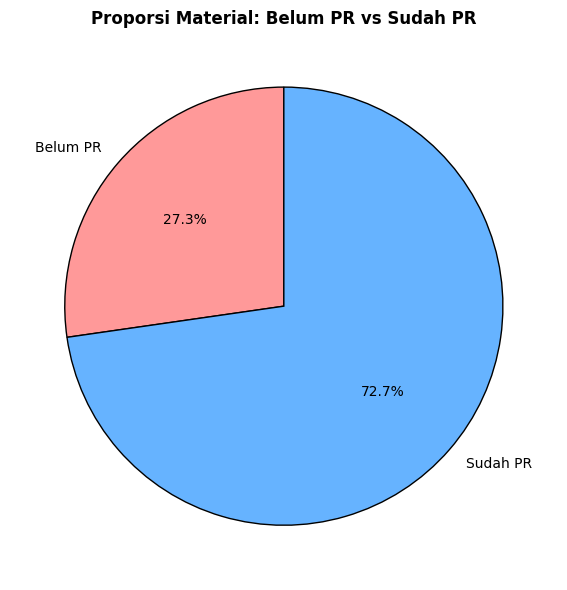

In [47]:
import matplotlib.pyplot as plt

# Data contoh (ganti dengan data asli Anda)
kategori = ['Belum PR', 'Sudah PR']
jumlah_material = [45, 120]

# Konfigurasi warna dan pie chart
colors = ['#ff9999', '#66b3ff']
plt.figure(figsize=(6, 6))

plt.pie(
    jumlah_material,
    labels=kategori,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    wedgeprops={'edgecolor': 'black'}
)

plt.title('Proporsi Material: Belum PR vs Sudah PR', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()